In [1]:
import sys
sys.path.append("../src")

import os
import numpy as np
import matplotlib.pyplot as plt

from SensorTasking import SpaceEnv
from SensorTasking import Metric, occlude_helper
from SensorTasking import RewardCallback, ActionHistoryCallback
from data_utils import gen_circle

from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common import results_plotter

In [2]:
def _set_up():

    mu = 0.012150584269940354

    v1 = np.array([0, 1, 1])
    v2 = np.array([1, 0, 0])

    R = gen_circle(v1, v2, T = 2*np.pi,step=0.00645, r = 0.00477887617, center = [1-mu, 0, 0])

    N = R.shape[0]

    target_orbits = np.zeros(shape=(N,3,2))

    target_orbits[:,:,0] = R

    v2 = np.array([1, 1, 0])
    R = gen_circle(v1, v2, T = 2*np.pi, step=0.00645, r = 0.00477887617, center = [1-mu, 0, 0])

    target_orbits[:,:,1] = R

    fname = "/Users/malavpatel/Research/SensorTasking/tmp/orbits/orbits.txt"
    states = np.loadtxt(fname, delimiter=",")

    agent_orbits = states[:,:3]
    
    occlude_metric = Metric(occlude_helper, cutoff=0.00451873048, params={"rB" : [1-mu, 0.0, 0.0]})

    
    return SpaceEnv(agent_orbits, target_orbits, occlude_metric)


In [3]:
def mask_fcn(env):
    return env.action_mask()

In [4]:
log_dir = "/Users/malavpatel/Research/SensorTasking/tmp/gym/"
os.makedirs(log_dir, exist_ok=True)

In [5]:
env = _set_up()
env = ActionMasker(env, mask_fcn)
env = Monitor(env, log_dir)
check_env(env)

In [6]:
callback = RewardCallback(check_freq=50, log_dir=log_dir, verbose=0)
action_history_list = []
acthistcallback = ActionHistoryCallback(action_history_list=action_history_list, verbose=0)
model = MaskablePPO("MultiInputPolicy", env, gamma=0.4, seed=32, verbose=0)
model.learn(total_timesteps=int(8e4), callback=[callback, acthistcallback])

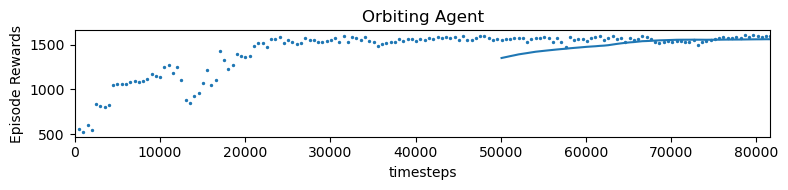

In [7]:
results_plotter.plot_results(
    [log_dir], 1e5, results_plotter.X_TIMESTEPS, "Orbiting Agent"
)

In [8]:
def moving_average(values, window):
    """
    Smooth values by doing a moving average
    :param values: (numpy array)
    :param window: (int)
    :return: (numpy array)
    """
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, "valid")


def plot_results(log_folder, title="Learning Curve"):
    """
    plot the results

    :param log_folder: (str) the save location of the results to plot
    :param title: (str) the title of the task to plot
    """
    x, y = results_plotter.ts2xy(results_plotter.load_results(log_folder), "timesteps")
    y = moving_average(y, window=50)
    # Truncate x
    x = x[len(x) - len(y) :]

    fig = plt.figure(title)
    plt.plot(x, y)
    plt.xlabel("Number of Timesteps")
    plt.ylabel("Rewards")
    plt.title(title + " Smoothed")
    plt.show()

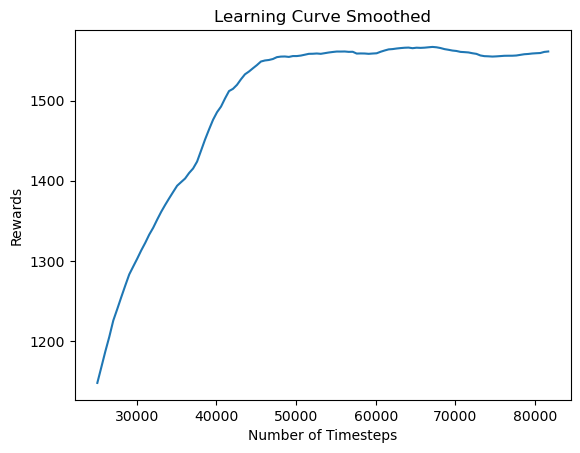

In [9]:
plot_results(log_dir)

In [10]:
action_history_list = np.array(action_history_list)
action_history_list[-1,:]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,

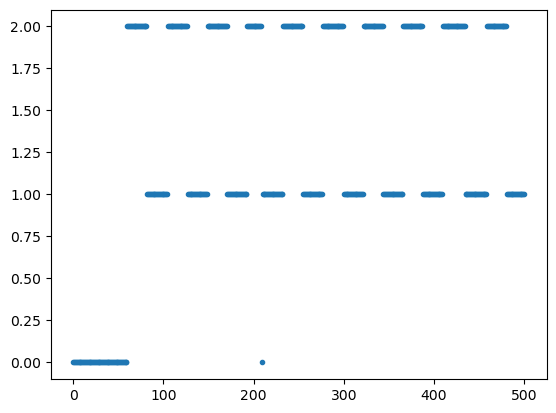

In [11]:
plt.scatter(range(len(action_history_list[-1,:])),action_history_list[-1,:], marker='.')